## 🔍 Explainability, Bias Analysis & Deployment

### 🔹 Purpose of this Notebook

This notebook explains model predictions using SHAP, evaluates fairness across groups, and prepares the model for deployment.

---

### 🔹 Objectives

* Interpret model predictions using SHAP
* Identify key features influencing fraud detection
* Evaluate model fairness across demographic groups
* Build a scoring script for real-world predictions


### Load the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shap

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    recall_score,
    precision_recall_curve
)
plt.style.use('default')

In [2]:
import joblib

automl = joblib.load("fraud_automl_model.pkl")
X_test = joblib.load("X_test.pkl")
y_test = joblib.load("y_test.pkl")

print("Loaded model and test data")

Loaded model and test data


In [3]:
automl.best_estimator

'lgbm'

# SHAP 

In [4]:
# SHAP EXPLAINER

model = automl.model.estimator

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values computed")

SHAP values computed


c:\Users\khair\anaconda3\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


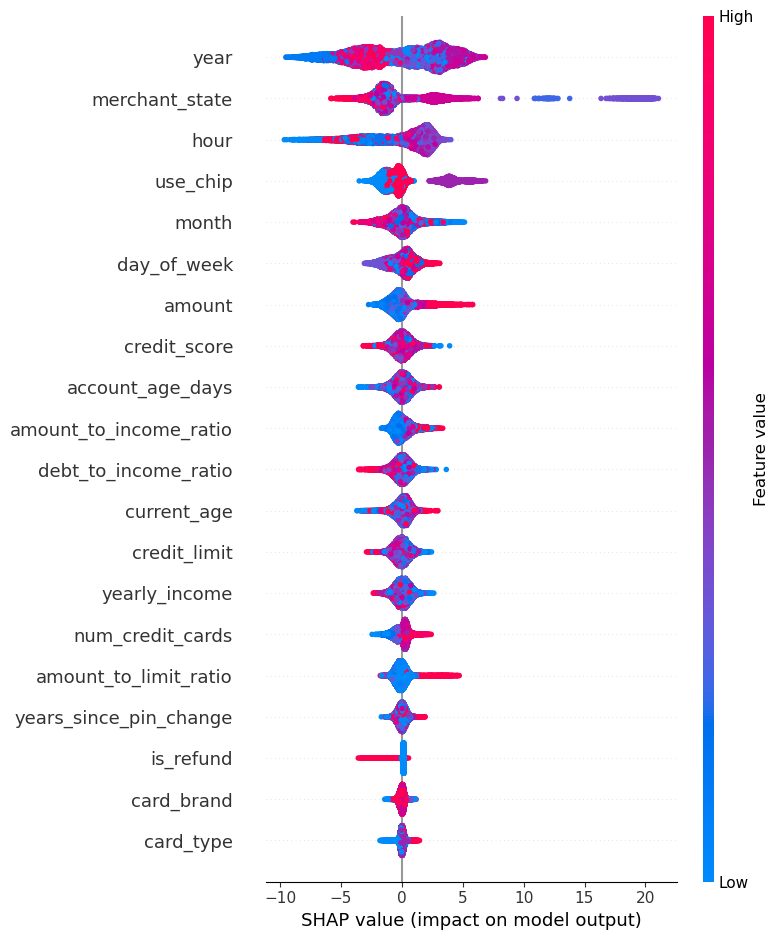

In [5]:
# ============================================================
# SHAP SUMMARY PLOT
# ============================================================

shap.summary_plot(shap_values, X_test)

**Interpretation:**

* SHAP analysis identifies the most important features affecting predictions
* Features such as year, merchant_state, hour, and amount have the highest impact
* Both feature value and direction influence fraud prediction
* This improves model transparency and interpretability 


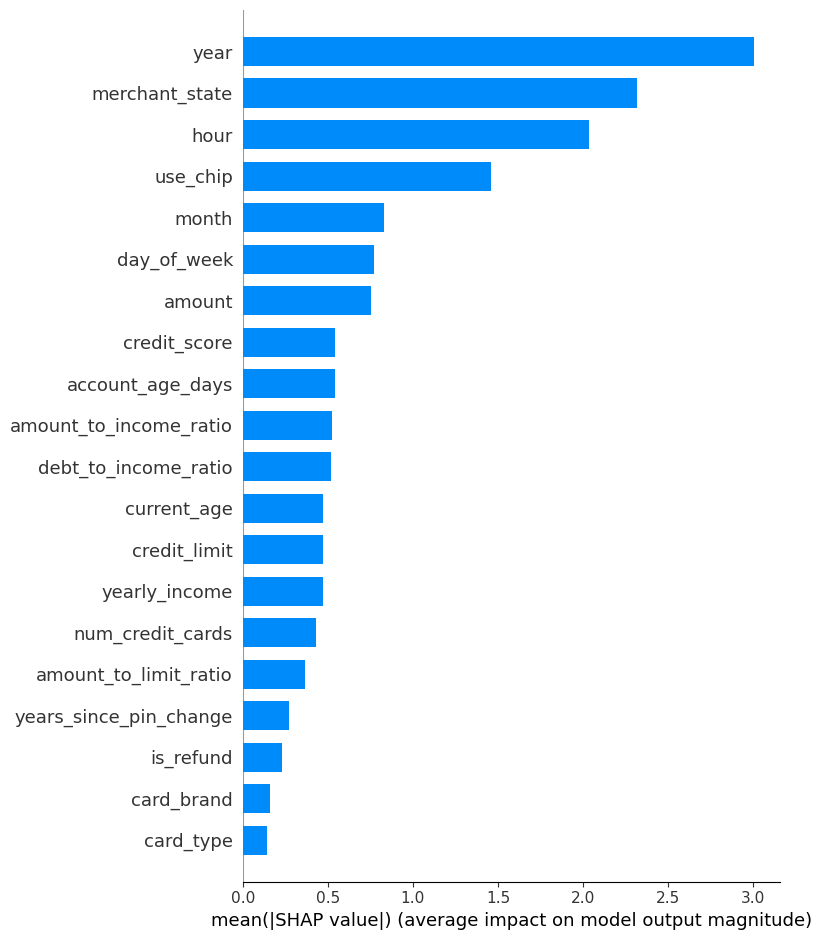

In [6]:
# bar plot
shap.summary_plot(shap_values, X_test, plot_type="bar")

**Interpretation:**

* Year, merchant_state, and hour are the most influential features
* Transaction amount and ratio-based features also contribute significantly
* Model decisions are driven by both temporal and financial features 


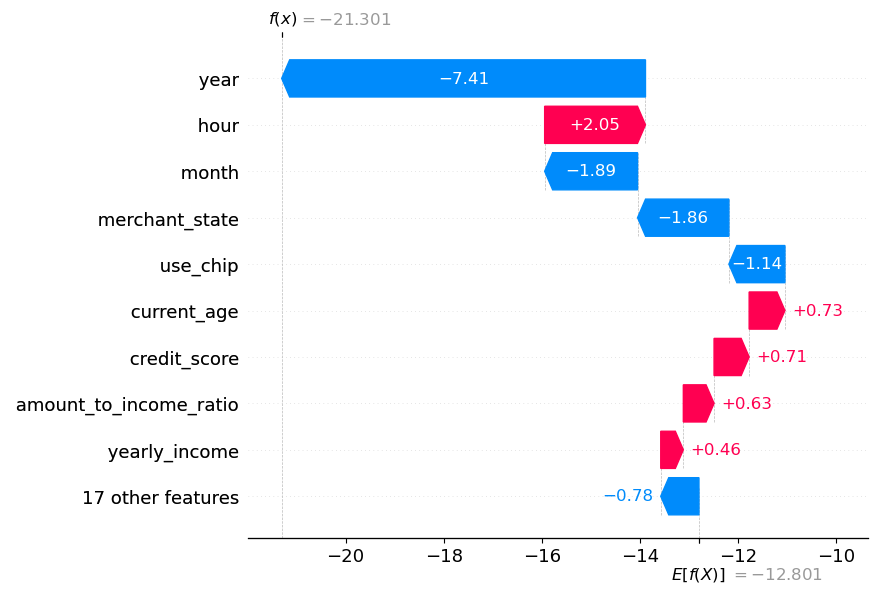

In [7]:
# First observation
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

**Interpretation:**

* Individual predictions can be explained using SHAP values
* Each feature contributes positively or negatively to the final prediction
* This allows understanding of why a specific transaction is classified as fraud


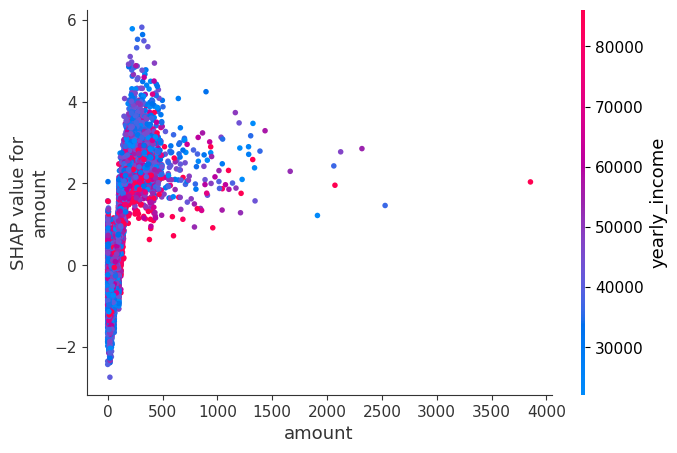

In [8]:
shap.dependence_plot("amount", shap_values, X_test)

**Interpretation:**

* Higher transaction amounts generally increase fraud probability
* Interaction with other features (e.g., income) affects the impact
* Confirms the importance of amount-related features


In [9]:
mean_shap = np.abs(shap_values).mean(axis=0)

feat_imp = pd.DataFrame({
    'Feature': X_test.columns,
    'Mean |SHAP|': mean_shap
}).sort_values(by='Mean |SHAP|', ascending=False)

print("\nTop SHAP Features:")
print(feat_imp.head(10))


Top SHAP Features:
                   Feature  Mean |SHAP|
15                    year     3.006289
2           merchant_state     2.316667
14                    hour     2.035414
1                 use_chip     1.457630
16                   month     0.827597
17             day_of_week     0.771847
0                   amount     0.751219
12            credit_score     0.544744
19        account_age_days     0.543883
23  amount_to_income_ratio     0.527178


# Bias Analysis

In [10]:
# Use tuned predictions (recommended)
threshold = 0.3
automl_prob = automl.predict_proba(X_test)[:,1]
automl_pred = (automl_prob >= threshold).astype(int)

In [11]:
# ============================================================
# BIAS ANALYSIS — GENDER
# ============================================================

df_eval = X_test.copy()
df_eval['actual'] = y_test
df_eval['pred'] = automl_pred

print("\n=== BIAS CHECK: GENDER ===")

for g in df_eval['gender'].unique():
    subset = df_eval[df_eval['gender'] == g]

    rec = recall_score(subset['actual'], subset['pred'])
    print(f"{g}: Recall = {rec:.4f}")


=== BIAS CHECK: GENDER ===
0: Recall = 0.9324
1: Recall = 0.9504


**Interpretation:**

* Recall is similar across gender groups
* Difference is small (~1.8%)
* No significant bias detected in gender predictions 


In [12]:
print("=== BIAS CHECK: AGE GROUP ===")

for a in df_eval['age_group'].unique():
    subset = df_eval[df_eval['age_group'] == a]

    rec = recall_score(subset['actual'], subset['pred'])
    print(f"{a}: Recall = {rec:.4f}")

=== BIAS CHECK: AGE GROUP ===
3: Recall = 0.9485
1: Recall = 0.9190
2: Recall = 0.9290
4: Recall = 0.9523
0: Recall = 1.0000
5: Recall = 0.0000


c:\Users\khair\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


**Interpretation:**

* Recall varies across age groups
* Some groups have insufficient samples, leading to unreliable metrics
* Overall, no strong bias observed, but results should be interpreted cautiously


In [13]:
from sklearn.metrics import recall_score

print("\n=== BIAS ANALYSIS ===")

groups = X_test['gender'].unique()   # or 'age_group'

for g in groups:
    idx = X_test['gender'] == g

    recall = recall_score(y_test[idx], automl_pred[idx])
    print(f"Group: {g} → Recall: {recall:.4f}")


=== BIAS ANALYSIS ===
Group: 0 → Recall: 0.9324
Group: 1 → Recall: 0.9504


In [14]:
recalls = []

for g in groups:
    idx = X_test['gender'] == g
    recalls.append(recall_score(y_test[idx], automl_pred[idx]))

gap = max(recalls) - min(recalls)

print(f"\nRecall Gap: {gap:.4f}")
print("Bias Detected?" , "YES" if gap > 0.05 else "NO")


Recall Gap: 0.0180
Bias Detected? NO


# Deployment - Scoring Script

In [15]:
import pickle

with open("model_package/encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

print(type(encoders))
print(list(encoders.keys())[:5])

<class 'dict'>
['use_chip', 'merchant_state', 'card_brand', 'card_type', 'gender']


In [16]:
import joblib
import pickle
import pandas as pd

# Load artifacts
model = joblib.load("model_package/fraud_model.pkl")

with open("model_package/feature_names.pkl", "rb") as f:
    features = pickle.load(f)

with open("model_package/threshold.pkl", "rb") as f:
    threshold = pickle.load(f)

with open("model_package/encoders.pkl", "rb") as f:
    encoders = pickle.load(f)


def preprocess_input(df):
    data = df.copy()

    # Ensure all required columns exist
    for col in features:
        if col not in data.columns:
            data[col] = 0

    # Apply encoding
    for col, le in encoders.items():
        if col in data.columns:
            data[col] = data[col].astype(str).map(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )

    # Ensure correct order
    data = data[features]

    return data


def predict_fraud(df):
    data = preprocess_input(df)

    prob = model.predict_proba(data)[:, 1]
    pred = (prob >= threshold).astype(int)

    return pd.DataFrame({
        "fraud_probability": prob,
        "prediction": pred
    })



In [17]:

scoring = """import pandas as pd
import pickle
import joblib

# Load artifacts
model = joblib.load("model_package/fraud_model.pkl")

with open("model_package/feature_names.pkl","rb") as f:
    features = pickle.load(f)

with open("model_package/threshold.pkl","rb") as f:
    threshold = pickle.load(f)

with open("model_package/encoders.pkl","rb") as f:
    encoders = pickle.load(f)


def preprocess_input(df):
    data = df.copy()

    # Ensure all required columns exist
    for col in features:
        if col not in data.columns:
            data[col] = 0

    # Apply encoding
    for col, le in encoders.items():
        if col in data.columns:
            data[col] = data[col].astype(str).map(
                lambda x: le.transform([x])[0] if x in le.classes_ else -1
            )

    # Ensure correct order
    data = data[features]

    return data


def predict_fraud(df):
    data = preprocess_input(df)

    prob = model.predict_proba(data)[:,1]
    pred = (prob >= threshold).astype(int)

    return pd.DataFrame({
        "fraud_probability": prob,
        "prediction": pred
    })


if __name__ == "__main__":
    df = pd.read_csv("model_package/sample_data.csv")
    print(predict_fraud(df))
"""


In [18]:
with open("model_package/scoring_script.py", "w") as f:
    f.write(scoring)

print("Scoring script ready")

Scoring script ready


**Interpretation:**

* A scoring function was created to generate predictions on new data
* The model uses the same features and preprocessing as training
* Predictions include both probability and classification
* This enables real-world deployment of the model 


In [19]:
predict_fraud(X_test.head(5))

,fraud_probability,prediction
0,2.575185e-08,0
1,9.559195e-07,0
2,7.578716e-08,0
3,5.810252e-08,0
4,1.981767e-09,0


In [21]:
fraud_samples = X_test[y_test == 1].head(5)
predict_fraud(fraud_samples)

,fraud_probability,prediction
0,7.578716e-08,0
1,6.595303e-01,1
2,8.037124e-03,0
3,5.607467e-05,0
4,8.616556e-08,0


**Interpretation:**

* The scoring function was tested on sample data
* Predictions are generated correctly with probability and class output
* Confirms that the deployment pipeline is working as expected 


## 🔹 Key Insights

* SHAP analysis provides transparency into model decisions

* Temporal and financial features are most important for fraud detection

* The model shows no significant bias across gender and age groups

* A complete deployment pipeline has been created

* model is suitable for real-world fraud detection scenarios
